# **Pastikan sudah di download terlebih dahulu colabnya, atau di salin. Terimakasih :)**

# Supervised Learning

## Classification

### Preparation

Untuk persiapan, kita akan memanggil seluruh library yang akan kita pakai pada project kali ini

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
%matplotlib inline

In [16]:
from google.colab import files
uploaded = files.upload()

Saving shopify.csv to shopify (1).csv


In [40]:
train = pd.read_csv('/content/shopify.csv')
train.head()

,order_id,order_date,customer_id,product_id,product_category,product_price,discount_percent,quantity,customer_country,traffic_source,payment_method,shipping_cost,rating,is_returned,discounted_price,revenue,profit
0,1,2023-04-13,14958,7824,Accessories,143.39,40,1,USA,Paid Ads,Credit Card,21.08,2.0,0,86.03,86.03,64.95
1,2,2024-03-11,26825,5557,Sports,746.49,15,4,UAE,Email,PayPal,5.48,3.7,0,634.52,2538.08,2532.60
2,3,2025-05-10,37450,2225,Electronics,641.06,5,5,Canada,Paid Ads,Apple Pay,11.27,3.2,0,609.01,3045.05,3033.78
3,4,2023-09-28,20691,7855,Footwear,512.39,0,3,UAE,Direct,Apple Pay,19.22,1.1,0,512.39,1537.17,1517.95
4,5,2023-04-17,24631,7789,Sports,415.89,25,3,UAE,Social Media,Debit Card,24.94,4.1,0,311.92,935.76,910.82


### Exploratory Data Analysis

In [41]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          60000 non-null  int64  
 1   order_date        60000 non-null  object 
 2   customer_id       60000 non-null  int64  
 3   product_id        60000 non-null  int64  
 4   product_category  60000 non-null  object 
 5   product_price     60000 non-null  float64
 6   discount_percent  60000 non-null  int64  
 7   quantity          60000 non-null  int64  
 8   customer_country  60000 non-null  object 
 9   traffic_source    60000 non-null  object 
 10  payment_method    60000 non-null  object 
 11  shipping_cost     60000 non-null  float64
 12  rating            60000 non-null  float64
 13  is_returned       60000 non-null  int64  
 14  discounted_price  60000 non-null  float64
 15  revenue           60000 non-null  float64
 16  profit            60000 non-null  float6

In [42]:
d = train.describe()
d

,order_id,customer_id,product_id,product_price,discount_percent,quantity,shipping_cost,rating,is_returned,discounted_price,revenue,profit
count,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000
mean,30000.500000,30035.075600,4504.738650,403.427068,18.151500,3.009567,13.521758,3.002440,0.148117,330.220212,994.098926,980.577168
std,17320.652413,11540.753215,2018.287018,230.045257,12.527663,1.414794,6.627934,1.152265,0.355219,197.114822,806.445785,806.508355
min,1.000000,10000.000000,1000.000000,5.010000,0.000000,1.000000,2.000000,1.000000,0.000000,3.080000,3.080000,-20.490000
25%,15000.750000,20037.750000,2751.750000,203.160000,5.000000,2.000000,7.760000,2.000000,0.000000,161.957500,355.620000,341.925000
50%,30000.500000,30079.000000,4503.500000,403.855000,20.000000,3.000000,13.580000,3.000000,0.000000,322.560000,760.470000,747.275000
75%,45000.250000,40036.250000,6257.000000,603.135000,30.000000,4.000000,19.230000,4.000000,0.000000,482.242500,1462.450000,1449.807500
max,60000.000000,49999.000000,7999.000000,799.990000,40.000000,5.000000,25.000000,5.000000,1.000000,799.900000,3999.500000,3989.950000


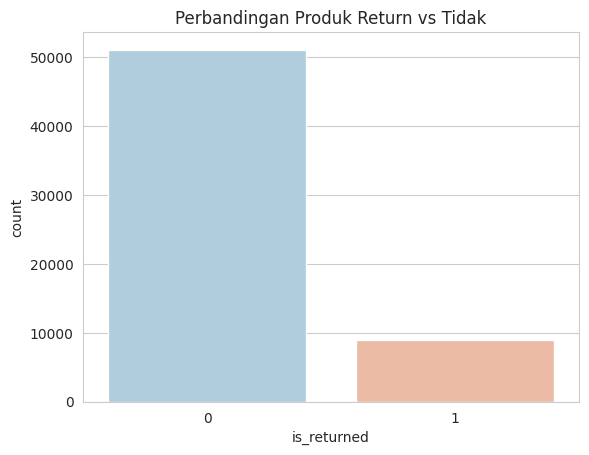

In [46]:
sns.set_style('whitegrid')

sns.countplot(
    x='is_returned',
    hue='is_returned',
    data=train,
    palette='RdBu_r',
    legend=False
)

plt.title('Perbandingan Produk Return vs Tidak')
plt.show()

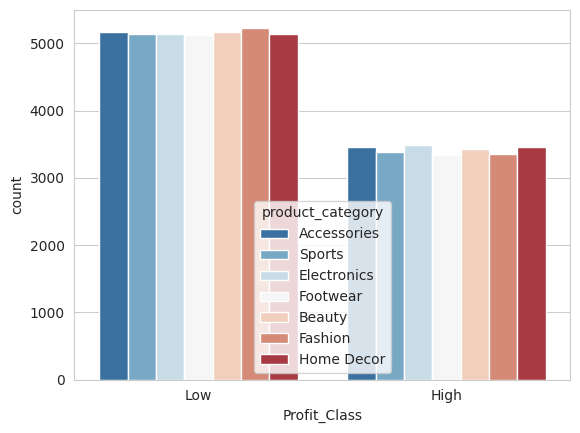

In [52]:
# Profit vs Product Category

sns.set_style('whitegrid')

sns.countplot(
    x='Profit_Class',
    hue='product_category',
    data=df,
    palette='RdBu_r'
)
plt.show()

In [59]:
median_profit = train['profit'].median()

train['Profit_Class'] = np.where(
    train['profit'] > median_profit,
    'High',
    'Low'
)

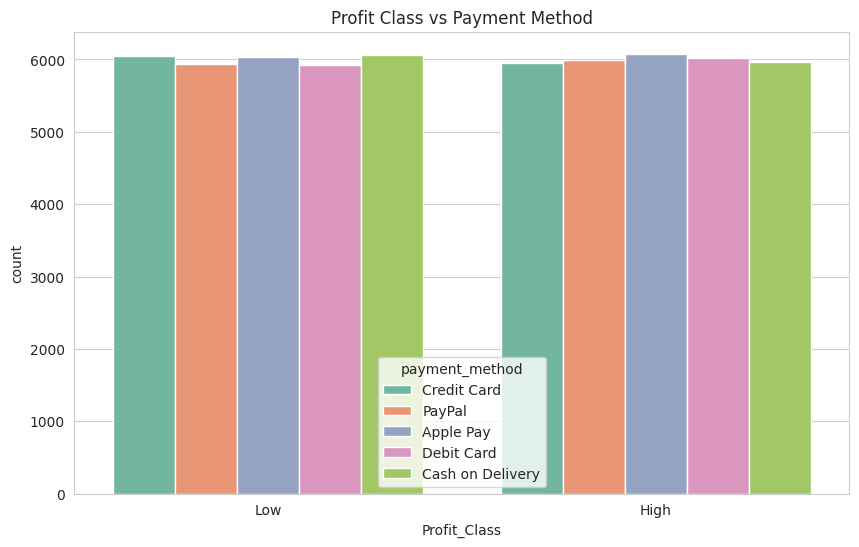

In [60]:
sns.set_style('whitegrid')

plt.figure(figsize=(10,6))

sns.countplot(
    x='Profit_Class',
    hue='payment_method',
    data=train,
    palette='Set2'   # ganti ini
)

plt.title('Profit Class vs Payment Method')
plt.show()

                  Profit_Class
product_category              
Accessories           0.400952
Beauty                0.398556
Electronics           0.403757
Fashion               0.390854
Footwear              0.394466
Home Decor            0.402326
Sports                0.397207


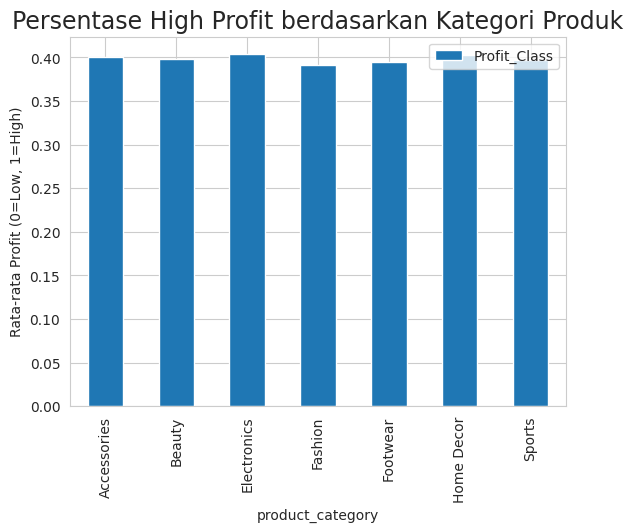

In [61]:
train['Profit_Class'] = train['profit'].apply(
    lambda x: 1 if x > 1000 else 0
)
f_profit = train.groupby('product_category')['Profit_Class'].mean()
f_profit = pd.DataFrame(f_profit)

print(f_profit)
import matplotlib.pyplot as plt

f_profit.plot.bar(y='Profit_Class')

plt.title("Persentase High Profit berdasarkan Kategori Produk", fontsize=17)
plt.ylabel("Rata-rata Profit (0=Low, 1=High)")
plt.show()

<Axes: xlabel='Profit_Class', ylabel='count'>

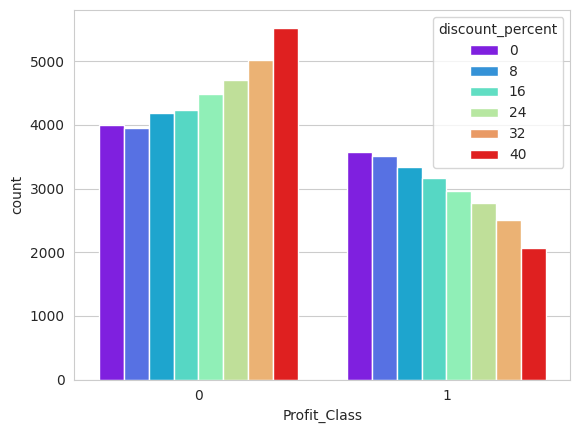

In [62]:
# Profit vs Discount
sns.countplot(x='Profit_Class', hue='discount_percent', data=train, palette='rainbow')

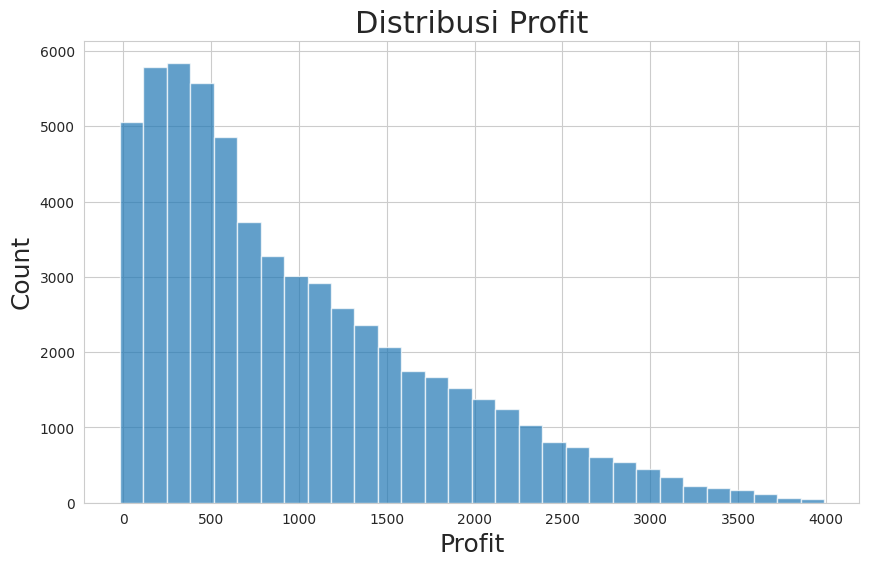

In [63]:
# Cek Histogram Profit
import matplotlib.pyplot as plt

plt.xlabel("Profit", fontsize=18)
plt.ylabel("Count", fontsize=18)
plt.title("Distribusi Profit", fontsize=22)

train['profit'].hist(bins=30, alpha=0.7, figsize=(10,6))

plt.show()

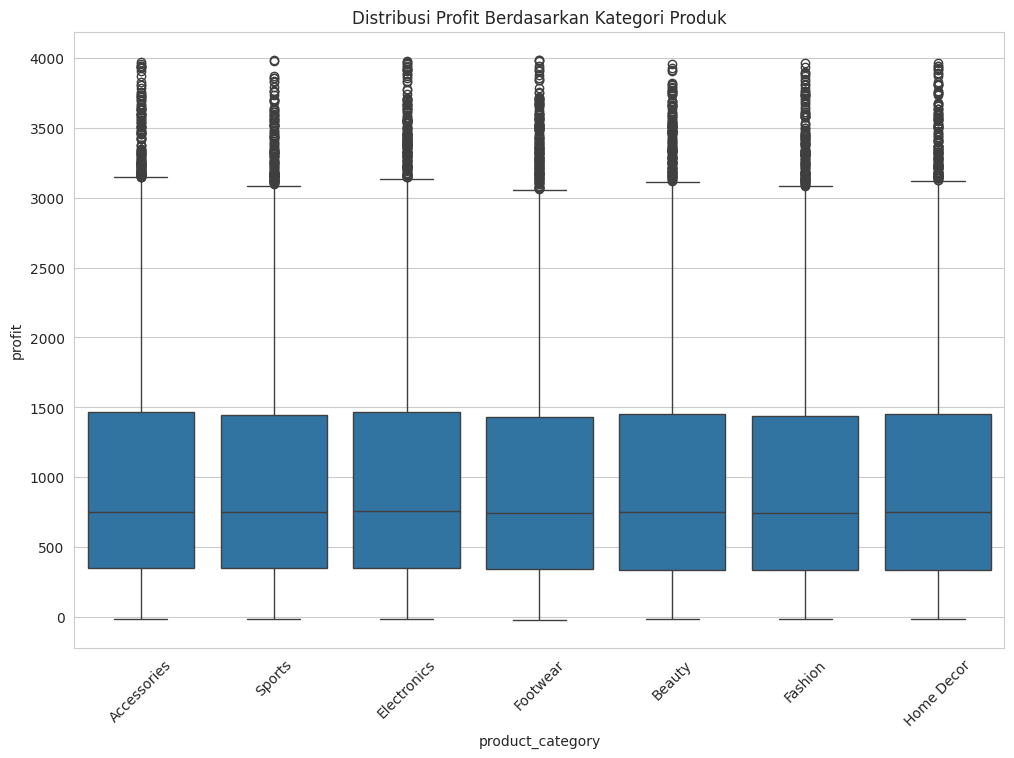

In [64]:
# Distribusi Profit Berdasarkan Kategori Produk

plt.figure(figsize=(12, 8))

sns.boxplot(x='product_category', y='profit', data=train)

plt.title("Distribusi Profit Berdasarkan Kategori Produk")
plt.xticks(rotation=45)
plt.show()

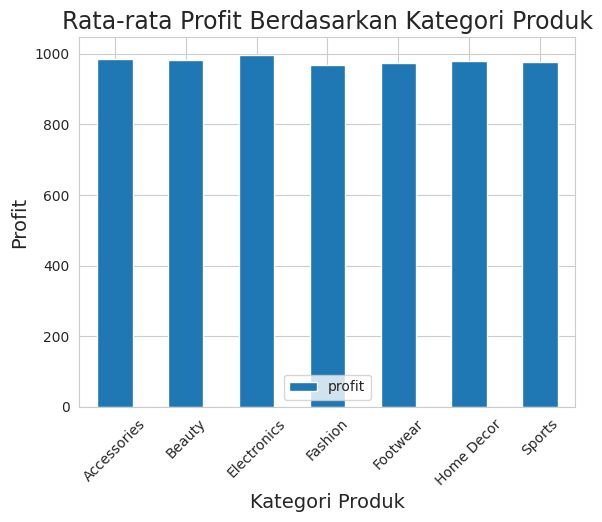

In [65]:
# Hitung rata-rata profit per kategori
f_profit = train.groupby('product_category')['profit'].mean()
f_profit = pd.DataFrame(f_profit)


f_profit.plot.bar(y='profit')

plt.title("Rata-rata Profit Berdasarkan Kategori Produk", fontsize=17)
plt.ylabel("Profit", fontsize=14)
plt.xlabel("Kategori Produk", fontsize=14)

plt.xticks(rotation=45)
plt.show()

### Fitur Engineering

In [66]:
# Rata-rata rating per kategori
avg_rating = train.groupby('product_category')['rating'].mean()

def impute_rating(cols):
    rating = cols[0]
    category = cols[1]

    if pd.isnull(rating):
        return avg_rating[category]
    else:
        return rating

In [67]:
train['Profit_Class'] = train['profit'].apply(
    lambda x: 'High' if x > 1000 else 'Low'
)

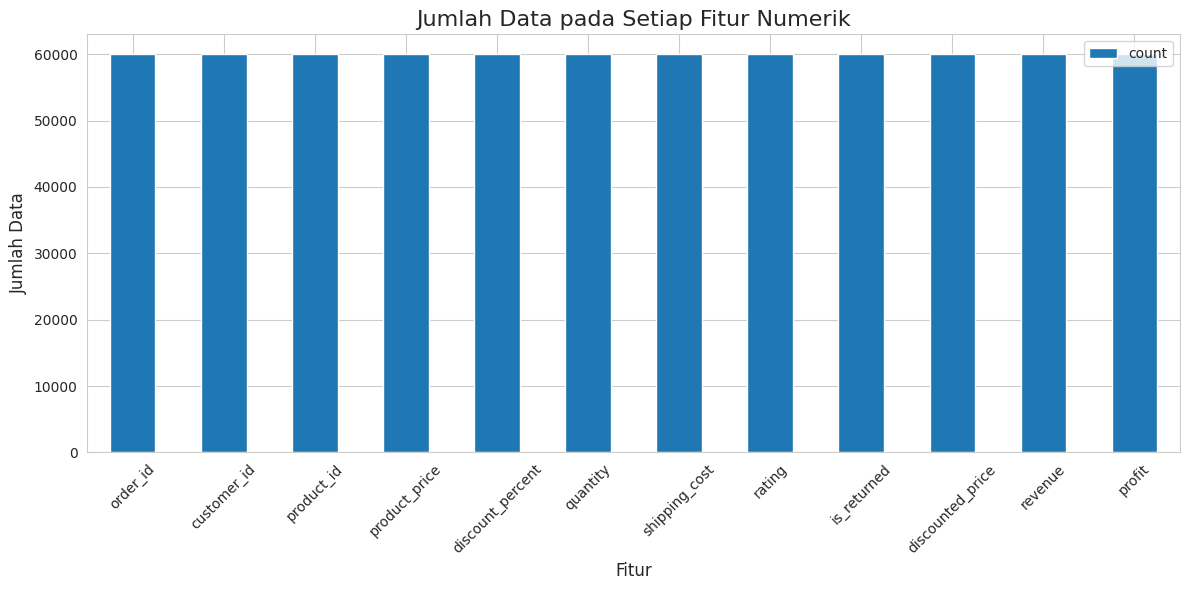

In [68]:
d = train.describe()
dT = d.T

dT.plot.bar(y='count', figsize=(12,6))

plt.title("Jumlah Data pada Setiap Fitur Numerik", fontsize=16)
plt.xlabel("Fitur", fontsize=12)
plt.ylabel("Jumlah Data", fontsize=12)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [69]:
#Drop hanya kalau kolomnya ada
train.drop(['order_id', 'customer_id'], axis=1, inplace=True, errors='ignore')
train.head()

,order_date,product_id,product_category,product_price,discount_percent,quantity,customer_country,traffic_source,payment_method,shipping_cost,rating,is_returned,discounted_price,revenue,profit,Profit_Class
0,2023-04-13,7824,Accessories,143.39,40,1,USA,Paid Ads,Credit Card,21.08,2.0,0,86.03,86.03,64.95,Low
1,2024-03-11,5557,Sports,746.49,15,4,UAE,Email,PayPal,5.48,3.7,0,634.52,2538.08,2532.60,High
2,2025-05-10,2225,Electronics,641.06,5,5,Canada,Paid Ads,Apple Pay,11.27,3.2,0,609.01,3045.05,3033.78,High
3,2023-09-28,7855,Footwear,512.39,0,3,UAE,Direct,Apple Pay,19.22,1.1,0,512.39,1537.17,1517.95,High
4,2023-04-17,7789,Sports,415.89,25,3,UAE,Social Media,Debit Card,24.94,4.1,0,311.92,935.76,910.82,Low


In [70]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = ['product_category', 'customer_country', 'traffic_source', 'payment_method']

for col in categorical_cols:
    train[col] = le.fit_transform(train[col])

train.head()

,order_date,product_id,product_category,product_price,discount_percent,quantity,customer_country,traffic_source,payment_method,shipping_cost,rating,is_returned,discounted_price,revenue,profit,Profit_Class
0,2023-04-13,7824,0,143.39,40,1,6,3,2,21.08,2.0,0,86.03,86.03,64.95,Low
1,2024-03-11,5557,6,746.49,15,4,4,1,4,5.48,3.7,0,634.52,2538.08,2532.60,High
2,2025-05-10,2225,2,641.06,5,5,1,3,0,11.27,3.2,0,609.01,3045.05,3033.78,High
3,2023-09-28,7855,4,512.39,0,3,4,0,0,19.22,1.1,0,512.39,1537.17,1517.95,High
4,2023-04-17,7789,6,415.89,25,3,4,4,3,24.94,4.1,0,311.92,935.76,910.82,Low


### Training

In [71]:
from sklearn.model_selection import train_test_split

X = train.drop('Profit_Class', axis=1)
y = train['Profit_Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

In [72]:
print(X_train.shape)
print(X_test.shape)

(42000, 15)
(18000, 15)


# **KNN**

In [73]:
# 1. Pisahkan fitur & target
X = df.drop(['order_id', 'customer_id', 'product_id', 'order_date', 'is_returned'], axis=1)
y = df['is_returned']

# 2. Encoding (WAJIB)
X = pd.get_dummies(X)

# 3. Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Scaling (WAJIB untuk KNN)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [74]:
from sklearn.neighbors import KNeighborsClassifier

clf1 = KNeighborsClassifier()
clf1.fit(X_train, y_train)



KNeighborsClassifier()

In [75]:
y_pred = clf1.predict(X_test)

### Evaluation

In [76]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred) #akurasi model
print(f'Akurasi Model KNN: {accuracy:.2f}')

print("Confusion Matrix:") #confusion matrix nya
print(confusion_matrix(y_test, y_pred))

print("Classification Report:") #laporan klasifikasi
print(classification_report(y_test, y_pred))

Akurasi Model KNN: 0.84
Confusion Matrix:
[[9984  283]
 [1685   48]]
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.97      0.91     10267
           1       0.15      0.03      0.05      1733

    accuracy                           0.84     12000
   macro avg       0.50      0.50      0.48     12000
weighted avg       0.75      0.84      0.79     12000



# **Naive Bayes**

In [77]:
from sklearn.naive_bayes import GaussianNB

# Inisialisasi model
nb = GaussianNB()

# Training
nb.fit(X_train, y_train)

# Prediksi data uji
y_pred_nb = nb.predict(X_test)

### Evaluation

In [79]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Evaluasi model
accuracy = accuracy_score(y_test, y_pred_nb)
print(f'Akurasi Model Naive Bayes: {accuracy:.2f}')

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_nb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb, zero_division=0))

Akurasi Model Naive Bayes: 0.86

Confusion Matrix:
[[10267     0]
 [ 1733     0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      1.00      0.92     10267
           1       0.00      0.00      0.00      1733

    accuracy                           0.86     12000
   macro avg       0.43      0.50      0.46     12000
weighted avg       0.73      0.86      0.79     12000



# **Decision Tree**

In [80]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_pred_dt = dt.predict(X_test)

### Evaluation

In [81]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Evaluasi model
accuracy = accuracy_score(y_test, y_pred_dt)
print(f'Akurasi Model Decision Tree: {accuracy:.2f}')

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

print("Classification Report:")
print(classification_report(y_test, y_pred_dt))

Akurasi Model Decision Tree: 0.73
Confusion Matrix:
[[8426 1841]
 [1411  322]]
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.82      0.84     10267
           1       0.15      0.19      0.17      1733

    accuracy                           0.73     12000
   macro avg       0.50      0.50      0.50     12000
weighted avg       0.75      0.73      0.74     12000



Karena yang lebih bagus adalah nilai evaluasinya model Naive Bayes, maka kita akan tes menggunakan data baru

In [82]:
import pandas as pd
import numpy as np

# ======================
# 1. LOAD DATA
# ======================
df = pd.read_csv('shopify.csv')

# ======================
# 2. PREPROCESSING
# ======================
# Pisahkan fitur & target
X = df.drop(['order_id', 'customer_id', 'product_id', 'order_date', 'is_returned'], axis=1)
y = df['is_returned']

# Encoding kategorikal
X = pd.get_dummies(X)

# ======================
# 3. SPLIT DATA
# ======================
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ======================
# 4. MODEL NAIVE BAYES
# ======================
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train.values, y_train)   # pakai .values biar konsisten

# ======================
# 5. EVALUASI
# ======================
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred_nb = nb.predict(X_test.values)

print("=== Evaluasi Naive Bayes ===")
print("Akurasi:", accuracy_score(y_test, y_pred_nb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb))

# ======================
# 6. PREDIKSI DATA BARU
# ======================

# Contoh data baru (transaksi)
new_data = pd.DataFrame([{
    'product_price': 100000,
    'discount_percent': 10,
    'quantity': 2,
    'shipping_cost': 5000,
    'rating': 4.5,
    'discounted_price': 90000,
    'revenue': 180000,
    'profit': 50000,

    # contoh kategori (akan otomatis disesuaikan)
    'product_category_Electronics': 1,
    'customer_country_Indonesia': 1,
    'traffic_source_Google': 1,
    'payment_method_Credit Card': 1
}])

# Samakan kolom dengan training
new_data = new_data.reindex(columns=X.columns, fill_value=0)

# Ubah ke numpy (biar tidak warning)
new_data = new_data.values

# Prediksi
new_prediction = nb.predict(new_data)
print("\nPrediksi (0 = Tidak Return, 1 = Return):", new_prediction[0])

# Probabilitas
proba = nb.predict_proba(new_data)
print("Probabilitas [Tidak Return, Return]:", proba[0])

=== Evaluasi Naive Bayes ===
Akurasi: 0.8555833333333334

Confusion Matrix:
 [[10267     0]
 [ 1733     0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.86      1.00      0.92     10267
           1       0.00      0.00      0.00      1733

    accuracy                           0.86     12000
   macro avg       0.43      0.50      0.46     12000
weighted avg       0.73      0.86      0.79     12000


Prediksi (0 = Tidak Return, 1 = Return): 0
Probabilitas [Tidak Return, Return]: [1. 0.]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


#---------------------------------------------------------------------------------------------------------------------------------


#---------------------------------------------------------------------------------------------------------------------------------

#---------------------------------------------------------------------------------------------------------------------------------

# **Contoh Penggunaan Parameter**

### jika kita mau mengubah parameter apa saja yang akan kita gunakan maka bisa dilakukan seperti ini

In [83]:
clf2 = KNeighborsClassifier(n_neighbors=5, weights='distance', metric='euclidean')
clf2.fit(X_train, y_train)

y_pred_knn = clf2.predict(X_test)

In [84]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred_knn) #akurasi model
print(f'Akurasi Model KNN: {accuracy:.2f}')

print("Confusion Matrix:") #confusion matrix nya
print(confusion_matrix(y_test, y_pred_knn))

print("Classification Report:") #laporan klasifikasi
print(classification_report(y_test, y_pred_knn))

Akurasi Model KNN: 0.83
Confusion Matrix:
[[9842  425]
 [1659   74]]
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.96      0.90     10267
           1       0.15      0.04      0.07      1733

    accuracy                           0.83     12000
   macro avg       0.50      0.50      0.49     12000
weighted avg       0.75      0.83      0.78     12000



### jika ingin mencoba semua parameter kita bisa menggunakan GridSearchCV

### Contoh penggunaan Model KNN dengan GridSearchCV

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# 1. Scoring
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score, average='macro', zero_division=0),
    'recall': make_scorer(recall_score, average='macro'),
    'f1': make_scorer(f1_score, average='macro')
}

# 2. Parameter grid
param_grid = {
    'n_neighbors': [3, 5, 7, 9],  # tambah variasi
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# 3. Model
knn = KNeighborsClassifier()

# 4. GridSearch
grid_search = GridSearchCV(
    knn,
    param_grid,
    cv=5,
    scoring=scoring,
    refit='f1',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

# 5. Hasil CV
cv_results = pd.DataFrame(grid_search.cv_results_)

cv_metrics = cv_results[[
    'params',
    'mean_test_accuracy',
    'mean_test_precision',
    'mean_test_recall',
    'mean_test_f1'
]]

print("\n=== Hasil Evaluasi Training (Cross-Validation) ===")
print(cv_metrics.sort_values(by='mean_test_f1', ascending=False))

Fitting 5 folds for each of 16 candidates, totalling 80 fits


In [ ]:
# Simpan hasil evaluasi ke file Excel
cv_metrics_sorted = cv_metrics.sort_values(by='mean_test_f1', ascending=False)
cv_metrics_sorted.to_excel("hasil_gridsearch_knn.xlsx", index=False)

print("Hasil telah disimpan ke 'hasil_gridsearch_knn.xlsx'")


In [ ]:
best_model = grid_search.best_estimator_
print("\n=== Parameter Terbaik ===")
print(grid_search.best_params_)

In [ ]:
y_pred = best_model.predict(X_test)
print("\n=== Evaluasi di Test Set ===")
print(f"Akurasi:  {accuracy_score(y_test, y_pred):.2f}")
print(f"Presisi:  {precision_score(y_test, y_pred, average='macro'):.2f}")
print(f"Recall:   {recall_score(y_test, y_pred, average='macro'):.2f}")
print(f"F1-Score: {f1_score(y_test, y_pred, average='macro'):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

In [ ]:
import pandas as pd
import numpy as np

# DATA BARU (TRANSAKSI)
new_data_1 = pd.DataFrame([{
    'product_price': 100000,
    'discount_percent': 10,
    'quantity': 2,
    'shipping_cost': 5000,
    'rating': 4.5,
    'discounted_price': 90000,
    'revenue': 180000,
    'profit': 50000,

    # contoh kategori
    'product_category_Electronics': 1,
    'customer_country_Indonesia': 1,
    'traffic_source_Google': 1,
    'payment_method_Credit Card': 1
}])


# SAMAKAN KOLOM
new_data_1 = new_data_1.reindex(columns=X.columns, fill_value=0)

# ubah ke numpy (biar konsisten dengan training)
new_data_1 = new_data_1.values

# PREDIKSI
prediction = best_model.predict(new_data_1)

print("Prediksi (0 = Tidak Return, 1 = Return):", prediction[0])